In [63]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [64]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [65]:
iris_df = pd.read_csv("datasets/iris.csv")

In [66]:
# inspecting
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [67]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [68]:
# drop unnecessary columns
X = iris_df.drop(columns=[
    "Id",
    "Species"
])


In [69]:
# duplication
X.duplicated().sum()
# but it's natural

np.int64(3)

In [70]:
# feature engineering
# no null values
X.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
dtype: int64

<Axes: xlabel='PetalLengthCm', ylabel='SepalWidthCm'>

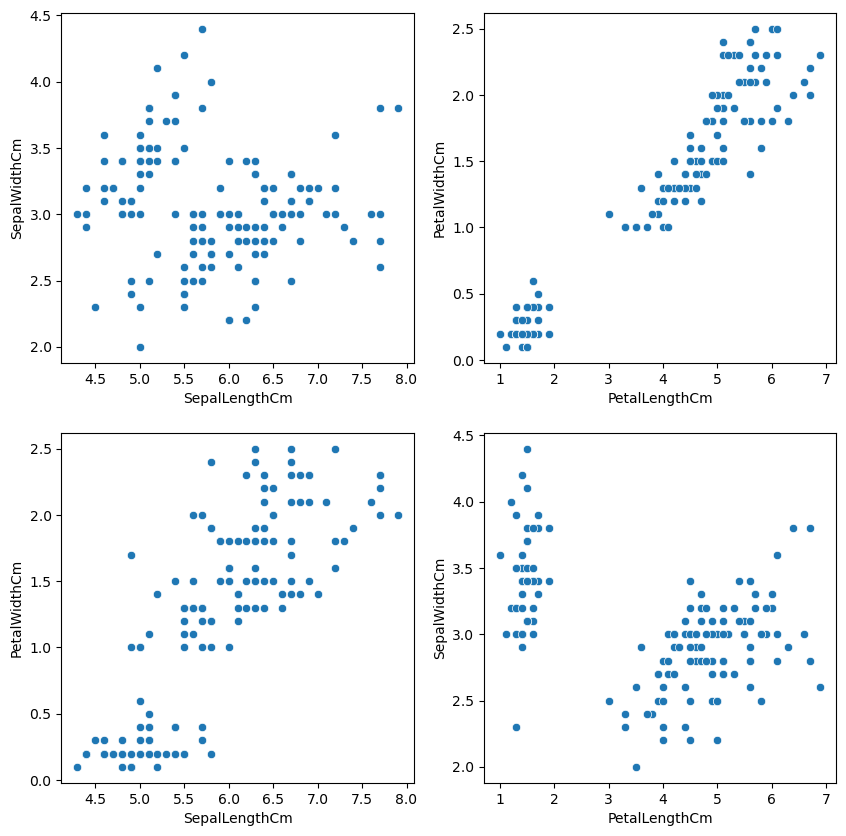

In [71]:
fig, ((axis1, axis2,), (axis3, axis4)) = plt.subplots(2, 2, figsize=(10, 10))
sns.scatterplot(
    data=X,
    x="SepalLengthCm",
    y="SepalWidthCm",
    ax=axis1,
)
sns.scatterplot(
    data=X,
    x="PetalLengthCm",
    y="PetalWidthCm",
    ax=axis2,
)
sns.scatterplot(
    data=X,
    x="SepalLengthCm",
    y="PetalWidthCm",
    ax=axis3,
)
sns.scatterplot(
    data=X,
    x="PetalLengthCm",
    y="SepalWidthCm",
    ax=axis4,
)


In [72]:
scaler = StandardScaler().set_output(transform="pandas")
X = scaler.fit_transform(X)

In [73]:
# choose optimal K
k_range = range(2, 11)
wcss = []
for k in k_range:
    km_model = KMeans(
        n_clusters=k,
        random_state=42
    )
    km_model.fit_predict(X)
    wcss.append(km_model.inertia_)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

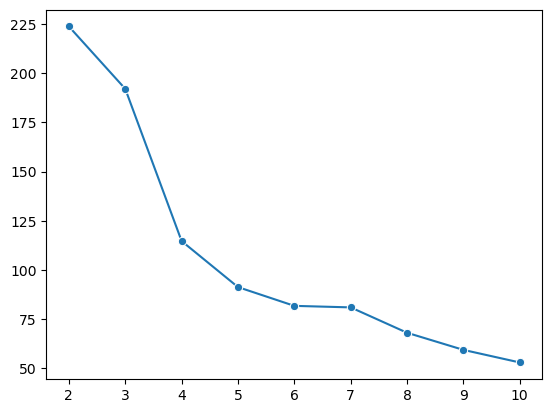

In [74]:
sns.lineplot(
    x=k_range,
    y=wcss,
    marker='o'
)

In [75]:
knee_locator = KneeLocator(
    k_range,
    wcss,
    curve="convex",
    direction="decreasing"
)
print(knee_locator.elbow)

5


In [76]:
ss = []
for k in k_range:
    km_model = KMeans(
        n_clusters=k,
        random_state=42 
   )
    labels = km_model.fit_predict(X)
    ss.append(
        silhouette_score(
            X,
            labels
        )
)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

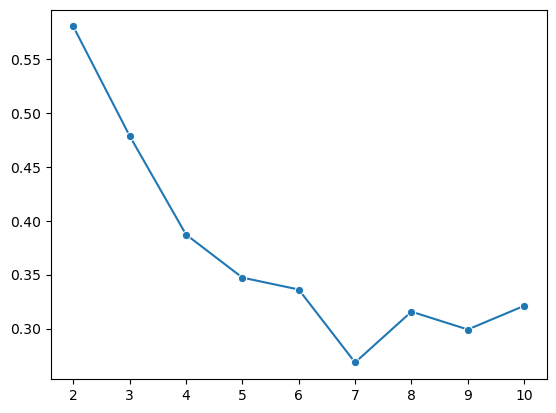

In [77]:
sns.lineplot(
    x=k_range,
    y=ss,
    marker='o'
)

In [78]:
km_model = KMeans(
    n_clusters=3,
    random_state=42
)
labels = km_model.fit_predict(X)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

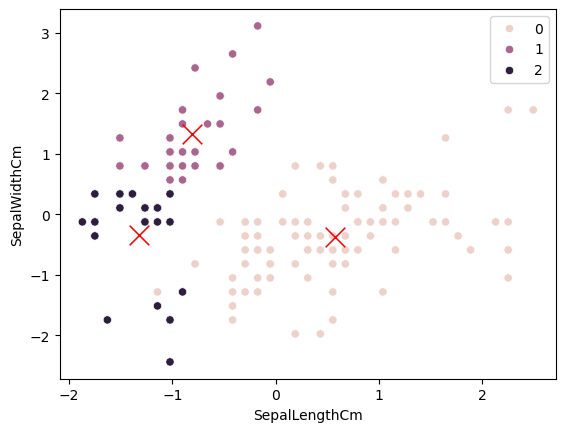

In [79]:
sns.scatterplot(
    x=X.iloc[:, 0],
    y=X.iloc[:, 1],
    hue=labels
)
sns.scatterplot(
    x=km_model.cluster_centers_[:, 0],
    y=km_model.cluster_centers_[:, 1],
    color="red",
    marker="x",
    s=200

)